# Final test evaluation — frozen InceptionV3
The checkpoint was selected using validation loss before opening the test set. This notebook performs one deterministic inference pass, then derives all metrics and illustrations from saved predictions. No fitting, checkpoint comparisons, threshold changes, or application changes are performed.

On rerun, a fingerprinted prediction cache is reused. An incomplete inference lock stops automatic repetition rather than silently evaluating again.

In [1]:
import os, json, hashlib, time
from pathlib import Path
from datetime import datetime, timezone
os.environ.setdefault("TF_DETERMINISTIC_OPS", "1")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from IPython.display import display, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "reports/final_split/final_split_manifest.csv").exists())
OUT = ROOT / "reports/inceptionv3_test"
OUT.mkdir(parents=True, exist_ok=True)
SEED = 42
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
try:
    tf.config.threading.set_intra_op_parallelism_threads(4)
    tf.config.threading.set_inter_op_parallelism_threads(2)
except RuntimeError:
    pass
def sha(path):
    with open(path, "rb") as f:
        return hashlib.file_digest(f, "sha256").hexdigest()
def save_json(name, value):
    (OUT / name).write_text(json.dumps(value, indent=2, allow_nan=False) + "\n", encoding="utf-8")
MODEL = ROOT / "model/inceptionv3_best_model.keras"
MANIFEST = ROOT / "reports/final_split/final_split_manifest.csv"
MAPPING = ROOT / "training/inceptionv3_class_indices.json"
training = json.loads((ROOT / "reports/inceptionv3_training/training_summary.json").read_text())
validation = json.loads((ROOT / "reports/inceptionv3_training/validation_metrics.json").read_text())
class_mapping = json.loads(MAPPING.read_text())
classes = [name for name, index in sorted(class_mapping.items(), key=lambda item: item[1])]
assert classes == ["Algal leaf spot", "Black spot", "Citrus canker", "Citrus pest", "Greening", "Healthy leaf"]
assert sorted(class_mapping.values()) == list(range(6))
assert class_mapping == training["class_indices"]
assert sha(MODEL) == training["final_model_sha256"]
assert sha(MANIFEST) == training["manifest_sha256"]
protected_paths = [MODEL, MANIFEST, MAPPING, ROOT / "model/resnet_best_model.keras", ROOT / "model/model_metadata.json",
                   ROOT / "reports/dataset_audit/manual_review_decisions.csv", ROOT / "app.py", ROOT / "streamlit_app.py"]
protected_paths += list((ROOT / "utils").glob("*.py"))
protected = {str(p): sha(p) for p in protected_paths if p.exists()}
manifest = pd.read_csv(MANIFEST)
assert len(manifest) == 2050 and not manifest.filepath.duplicated().any()
assert manifest.groupby("source_group_id").new_split.nunique().max() == 1
test = manifest.loc[manifest.new_split.eq("test")].reset_index(drop=True)
assert len(test) == 307 and not test.filepath.duplicated().any()
assert set(test["class"]) == set(classes)
assert all((ROOT / p).is_file() for p in test.filepath)
assert all(sha(ROOT / row.filepath) == row.sha256 for row in test.itertuples())
dataset_stats = {str(p): (p.stat().st_size, p.stat().st_mtime_ns) for p in (ROOT / "dataset").rglob("*") if p.is_file()}
display(test.groupby("class").size().rename("test images").to_frame())
print("Verified 307 unique test images; frozen model and manifest hashes match training.")
print("TensorFlow:", tf.__version__, "Devices:", tf.config.list_physical_devices())

Verified 307 unique test images; frozen model and manifest hashes match training.
TensorFlow: 2.21.0 Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


,test images
class,
Algal leaf spot,47
Black spot,49
Citrus canker,56
Citrus pest,58
Greening,52
Healthy leaf,45


## Deterministic inputs and one inference pass
RGB decoding, float32 bilinear resize to 299 × 299, then InceptionV3 `preprocess_input`, in manifest order. No augmentation or shuffle. The reported loss uses the same sparse categorical cross-entropy **including model regularization** as validation. Cross-entropy without regularization is also recorded separately.

All probabilities are collected in the same pass that computes loss; there is no second evaluate/predict pass.

In [2]:
preprocessing = {"decode": "tf.io.decode_image, channels=3, expand_animations=False", "image_size": [299, 299],
                 "resize": "float32 bilinear, default antialias=False", "normalization": "tf.keras.applications.inception_v3.preprocess_input",
                 "augmentation": False, "shuffle": False, "batch_size": 16, "order": "manifest test row order"}
fingerprint = {"model_sha256": sha(MODEL), "manifest_sha256": sha(MANIFEST), "mapping_sha256": sha(MAPPING),
               "test_filepaths": test.filepath.tolist(), "preprocessing": preprocessing}
cache = OUT / "frozen_test_inference.npz"
lock = OUT / "inference_started.json"
y_true = test["class"].map(class_mapping).to_numpy(dtype=np.int32)
if cache.exists():
    with np.load(cache, allow_pickle=False) as stored:
        assert json.loads(str(stored["fingerprint"])) == fingerprint, "Cached artifacts differ; do not silently re-evaluate."
        probabilities = stored["probabilities"]
        losses = stored["batch_losses"]
        batch_sizes = stored["batch_sizes"]
        timestamp = str(stored["timestamp"])
        inference_seconds = float(stored["inference_seconds"])
        assert np.array_equal(stored["y_true"], y_true)
    print("Reusing the original single-pass predictions; no model inference on this run.")
else:
    assert not lock.exists(), "A prior inference started without a complete cache. Inspect the failure before any further evaluation."
    model = tf.keras.models.load_model(MODEL, compile=False)
    assert model.output_shape[-1] == len(classes)
    assert tuple(model.input_shape[1:]) == (299, 299, 3)
    model.compile(loss="sparse_categorical_crossentropy")
    def decode_resize(path, label):
        raw = tf.io.read_file(path)
        image = tf.io.decode_image(raw, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])
        return tf.image.resize(tf.cast(image, tf.float32), (299, 299), method="bilinear"), label
    dataset = tf.data.Dataset.from_tensor_slices(([(ROOT / p).as_posix() for p in test.filepath], y_true))
    dataset = dataset.map(decode_resize, num_parallel_calls=2, deterministic=True).batch(16)
    dataset = dataset.map(lambda x, y: (tf.keras.applications.inception_v3.preprocess_input(x), y), num_parallel_calls=2, deterministic=True)
    options = tf.data.Options()
    options.experimental_deterministic = True
    options.threading.private_threadpool_size = 2
    dataset = dataset.with_options(options).prefetch(2)
    timestamp = datetime.now(timezone.utc).isoformat()
    with lock.open("x", encoding="utf-8") as f:
        json.dump({"timestamp": timestamp, "fingerprint": fingerprint}, f, indent=2)
    started = time.perf_counter()
    batches, losses, batch_sizes = [], [], []
    for images, labels in dataset:
        predictions = model(images, training=False)
        losses.append(float(model.compute_loss(x=images, y=labels, y_pred=predictions, training=False).numpy()))
        batch_sizes.append(int(labels.shape[0]))
        batches.append(predictions.numpy())
    inference_seconds = time.perf_counter() - started
    probabilities = np.concatenate(batches)
    temporary = OUT / "frozen_test_inference.tmp.npz"
    np.savez_compressed(temporary, probabilities=probabilities, y_true=y_true, batch_losses=losses,
                        batch_sizes=batch_sizes, fingerprint=json.dumps(fingerprint, sort_keys=True),
                        timestamp=timestamp, inference_seconds=inference_seconds)
    temporary.replace(cache)
assert probabilities.shape == (307, 6) and np.isfinite(probabilities).all()
assert np.allclose(probabilities.sum(axis=1), 1., atol=1e-5)
assert sum(batch_sizes) == 307
y_pred = probabilities.argmax(axis=1)
print("Single-pass predictions saved. Inference seconds:", round(inference_seconds, 2))

Cause: Unable to locate the source code of <function decode_resize at 0x0000017D3E9D5800>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: source code not available
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x0000017D350AB9C0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Single-pass predictions saved. Inference seconds: 24.65


## Final metrics and per-class results
Predictions use the unchanged argmax rule. Values in JSON and CSV retain full useful precision.

In [3]:
report = classification_report(y_true, y_pred, labels=list(range(6)), target_names=classes, output_dict=True, zero_division=0)
metrics = {"loss": float(np.average(losses, weights=batch_sizes)), "accuracy": float(accuracy_score(y_true, y_pred)),
           "macro_precision": float(report["macro avg"]["precision"]), "macro_recall": float(report["macro avg"]["recall"]),
           "macro_f1": float(report["macro avg"]["f1-score"]), "weighted_f1": float(report["weighted avg"]["f1-score"]),
           "cross_entropy_without_regularization": float(tf.keras.losses.sparse_categorical_crossentropy(y_true, probabilities).numpy().mean())}
save_json("test_metrics.json", metrics)
per_class = pd.DataFrame([{"class": name, "support": int(report[name]["support"]), "precision": report[name]["precision"],
                           "recall": report[name]["recall"], "F1": report[name]["f1-score"]} for name in classes])
per_class.to_csv(OUT / "test_classification_report.csv", index=False)
cm = confusion_matrix(y_true, y_pred, labels=list(range(6)))
pd.DataFrame(cm, index=pd.Index(classes, name="true_class"), columns=classes).to_csv(OUT / "test_confusion_matrix.csv")
predictions_table = test[["filepath", "filename", "class"]].rename(columns={"class": "true_class"}).copy()
predictions_table["predicted_class"] = [classes[i] for i in y_pred]
predictions_table["confidence"] = probabilities.max(axis=1)
predictions_table["correct"] = y_true == y_pred
top3 = np.argsort(-probabilities, axis=1, kind="stable")[:, :3]
for rank in range(3):
    predictions_table[f"top_{rank+1}_class"] = [classes[i] for i in top3[:, rank]]
    predictions_table[f"top_{rank+1}_probability"] = probabilities[np.arange(len(test)), top3[:, rank]]
predictions_table.to_csv(OUT / "test_predictions.csv", index=False)
display(pd.Series(metrics, name="test").to_frame())
display(per_class)
strongest = per_class.loc[np.isclose(per_class.F1, per_class.F1.max()), "class"].tolist()
errors_by_class = cm.sum(axis=1) - np.diag(cm)
most_errors = [classes[i] for i in np.flatnonzero(errors_by_class == errors_by_class.max())] if errors_by_class.max() else []
confusions = sorted([{"true_class": classes[i], "predicted_class": classes[j], "count": int(cm[i,j])}
                     for i in range(6) for j in range(6) if i != j and cm[i,j]], key=lambda x: -x["count"])
print("Highest observed F1:", ", ".join(strongest))
print("Most incorrect predictions by true class:", most_errors)
display(pd.DataFrame(confusions))

Highest observed F1: Healthy leaf
Most incorrect predictions by true class: ['Citrus canker', 'Greening']


,test
loss,0.136189
accuracy,0.954397
macro_precision,0.956446
macro_recall,0.955807
macro_f1,0.955074
weighted_f1,0.953876
cross_entropy_without_regularization,0.130356


,class,support,precision,recall,F1
0,Algal leaf spot,47,0.940000,1.000000,0.969072
1,Black spot,49,0.960000,0.979592,0.969697
2,Citrus canker,56,0.961538,0.892857,0.925926
3,Citrus pest,58,0.920635,1.000000,0.958678
4,Greening,52,0.978723,0.884615,0.929293
5,Healthy leaf,45,0.977778,0.977778,0.977778


,true_class,predicted_class,count
0,Citrus canker,Citrus pest,4
1,Greening,Algal leaf spot,3
2,Black spot,Citrus canker,1
3,Citrus canker,Black spot,1
4,Citrus canker,Greening,1
5,Greening,Black spot,1
6,Greening,Citrus canker,1
7,Greening,Healthy leaf,1
8,Healthy leaf,Citrus pest,1


## Confusion matrices
Rows are true labels and columns are predictions. Percentages are normalized within each true class.

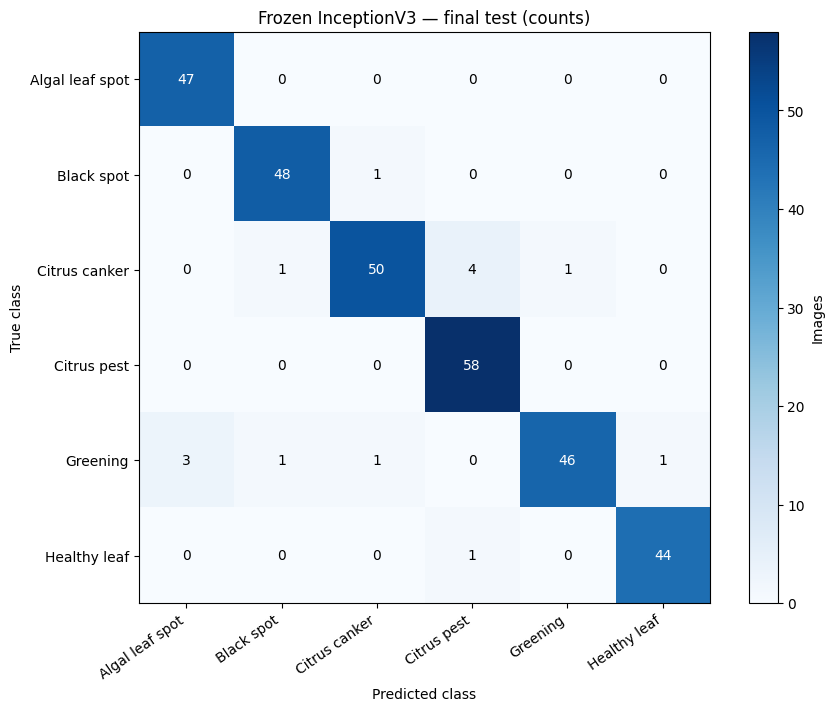

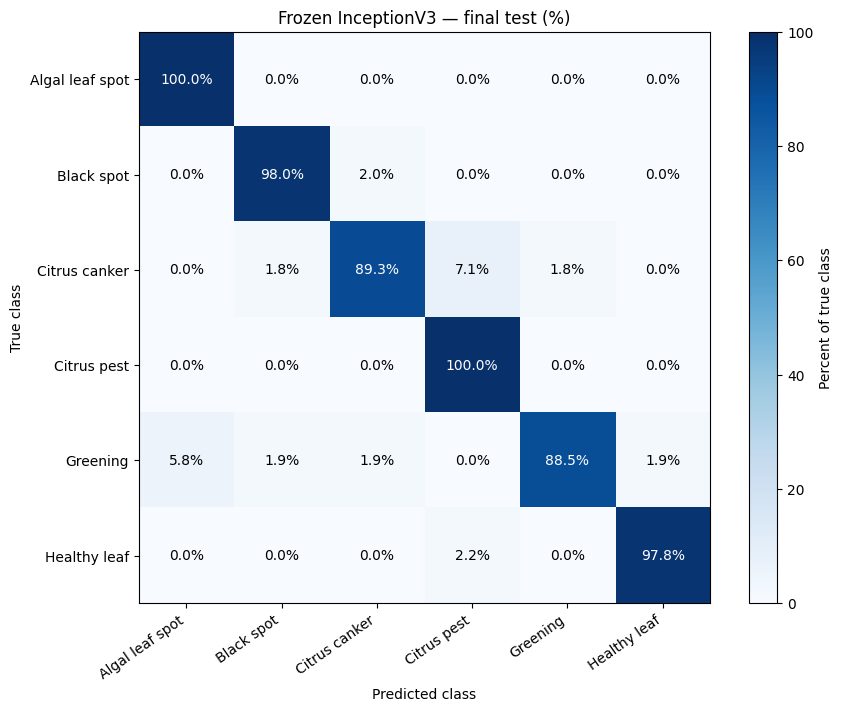

In [4]:
for normalized, filename in [(False, "test_confusion_matrix.png"), (True, "test_confusion_matrix_normalized.png")]:
    values = cm / cm.sum(axis=1, keepdims=True) * 100 if normalized else cm
    fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
    plot = ax.imshow(values, cmap="Blues", vmin=0, vmax=100 if normalized else None)
    fig.colorbar(plot, ax=ax, label="Percent of true class" if normalized else "Images")
    for i in range(6):
        for j in range(6):
            text = f"{values[i,j]:.1f}%" if normalized else str(cm[i,j])
            ax.text(j, i, text, ha="center", va="center", color="white" if values[i,j] > values.max()/2 else "black")
    ax.set(xticks=range(6), yticks=range(6), xticklabels=classes, yticklabels=classes,
           xlabel="Predicted class", ylabel="True class", title="Frozen InceptionV3 — final test" + (" (%)" if normalized else " (counts)"))
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
    fig.savefig(OUT / filename, dpi=150, bbox_inches="tight")
    plt.show()

## Descriptive error inspection
These illustrations do not drive any model changes. Confidence is the largest softmax probability, not a calibrated probability of correctness. Representative errors are selected deterministically across observed true/predicted class combinations.

Correct: 293 Incorrect: 14


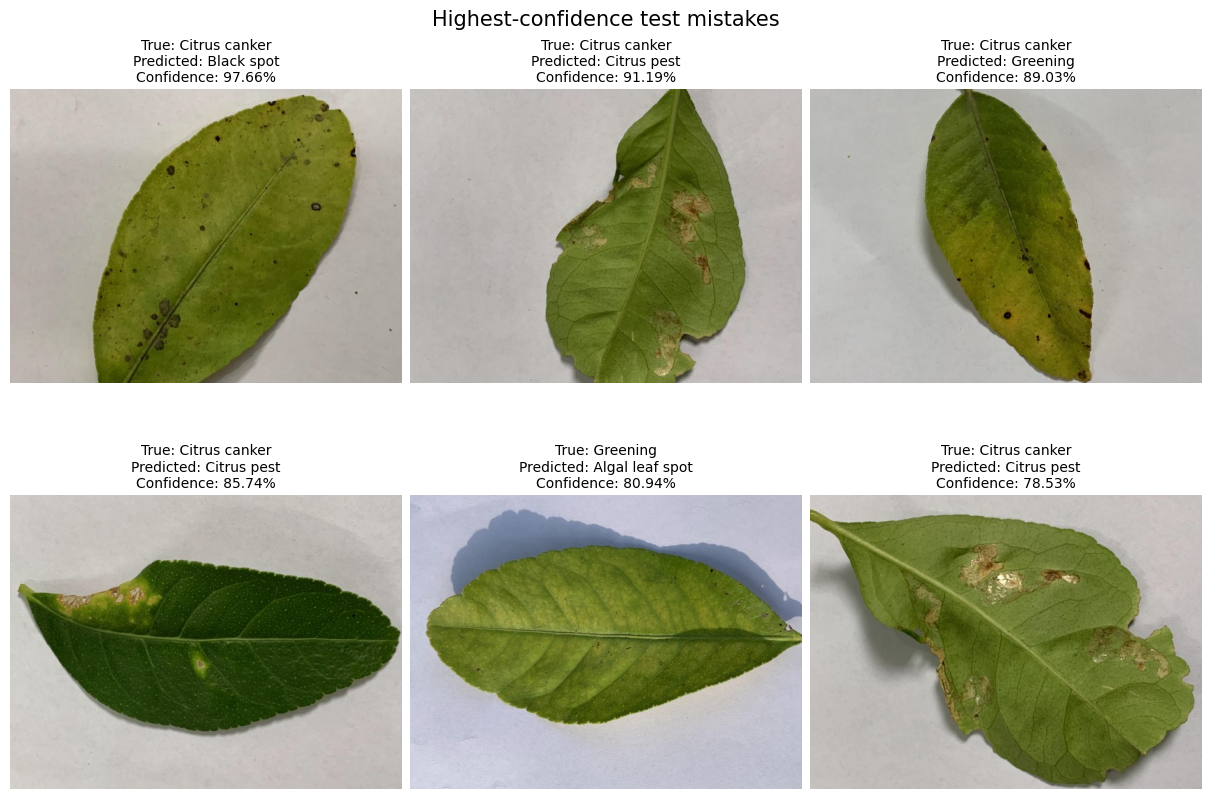

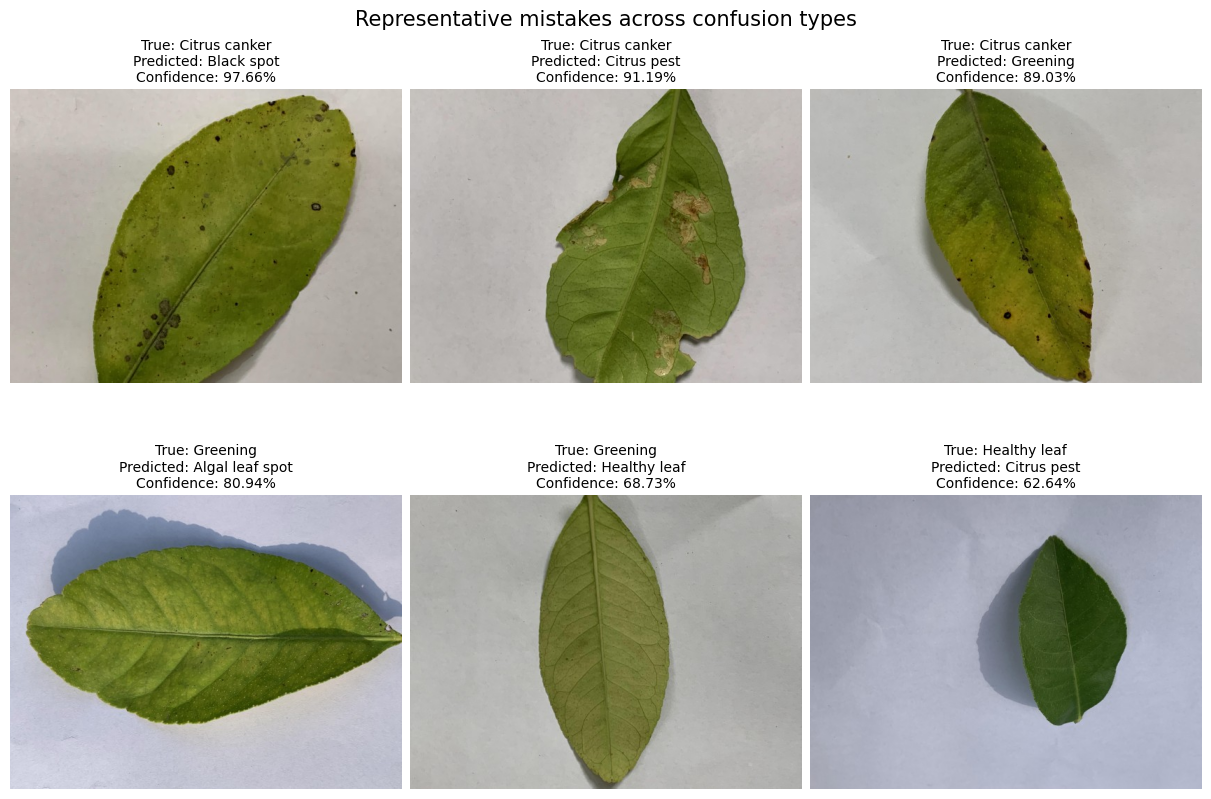

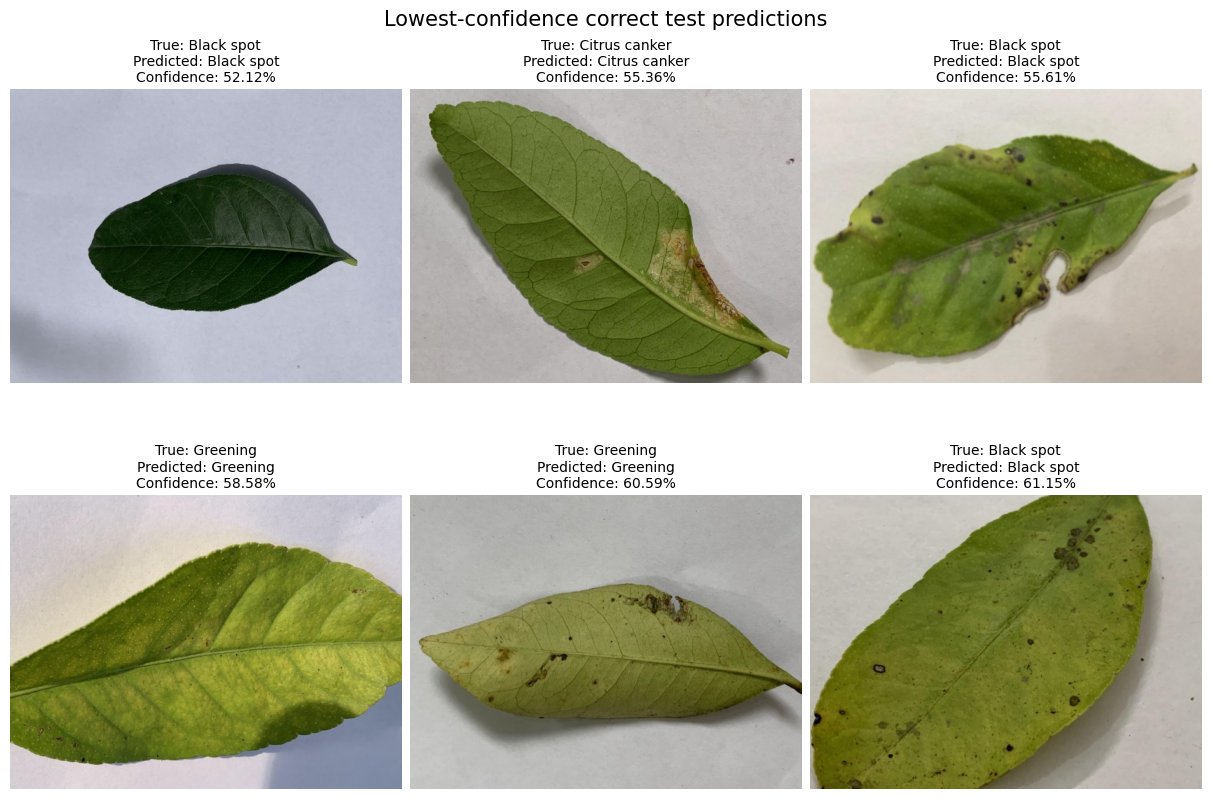

In [5]:
errors = predictions_table.loc[~predictions_table.correct].sort_values("confidence", ascending=False)
representative = errors.drop_duplicates(["true_class", "predicted_class"]).head(6)
low_correct = predictions_table.loc[predictions_table.correct].sort_values("confidence").head(6)
def show_examples(frame, title, filename):
    count = len(frame)
    columns = 3
    rows = max(1, (count + columns - 1) // columns)
    fig, axes = plt.subplots(rows, columns, figsize=(12, rows * 4.2), squeeze=False, layout="constrained")
    for ax in axes.flat:
        ax.axis("off")
    for ax, row in zip(axes.flat, frame.itertuples()):
        with Image.open(ROOT / row.filepath) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(f"True: {row.true_class}\nPredicted: {row.predicted_class}\nConfidence: {row.confidence:.2%}", fontsize=10)
    if not count:
        axes[0, 0].text(0.5, 0.5, "No examples in this category", ha="center")
    fig.suptitle(title, fontsize=15)
    fig.savefig(OUT / filename, dpi=140, bbox_inches="tight")
    plt.show()
show_examples(errors.head(6), "Highest-confidence test mistakes", "test_error_examples.png")
show_examples(representative, "Representative mistakes across confusion types", "test_representative_errors.png")
show_examples(low_correct, "Lowest-confidence correct test predictions", "test_low_confidence_correct.png")
print("Correct:", int(predictions_table.correct.sum()), "Incorrect:", len(errors))

## Validation comparison and generalization gaps
Validation metrics are read from the completed training run; no validation or training inference is repeated. The training accuracy was recorded with augmentation and dropout during the selected epoch, so it is not directly comparable to deterministic evaluation accuracy. A small difference alone does not establish overfitting.

**Observed results:** validation accuracy is 95.7792% and test accuracy is 95.4397%, a difference of 0.3395 percentage points. Loss is also close (0.136674 validation versus 0.136189 test), as is macro F1 (95.8629% versus 95.5074%). These results are descriptively consistent; they are not proof of equivalent performance or independent biological sources. The selected-epoch augmented training accuracy is 97.2125%, 1.773 percentage points above test accuracy. This gap alone does not establish overfitting. The previously observed later fine-tuning deterioration was already handled by validation-based checkpoint selection.

Healthy leaf has the highest observed F1 (97.78%). Citrus canker and Greening each have six errors; the largest confusion is Citrus canker predicted as Citrus pest (four images). These are descriptions of this test sample only.

In [6]:
comparison = pd.DataFrame([{"metric": key, "validation": validation[key], "test": metrics[key]}
                           for key in ["accuracy", "loss", "macro_precision", "macro_recall", "macro_f1"]])
comparison.to_csv(OUT / "validation_vs_test_metrics.csv", index=False)
display(comparison)
train_accuracy = training.get("selected_epoch_augmented_training_accuracy")
gap = validation["accuracy"] - metrics["accuracy"]
print(f"Validation minus test accuracy: {100*gap:.3f} percentage points.")
if train_accuracy is not None:
    print(f"Selected-epoch augmented training accuracy: {train_accuracy:.6%}")
    print(f"Training minus validation: {100*(train_accuracy-validation['accuracy']):.3f} percentage points.")
    print(f"Training minus test: {100*(train_accuracy-metrics['accuracy']):.3f} percentage points.")
print("These are observed differences on small held-out samples; they do not by themselves establish overfitting or biological-source independence.")
limitation = ("410 unresolved Category C/D similarity candidate pairs cross the new split. They were not treated as proven same-source relationships. "
              "The split passes all enforced leakage checks, but complete biological-source independence is not proven.")
integrity = ("The frozen model was evaluated once on the untouched test split. Test results were not used for model selection, "
             "hyperparameter tuning, augmentation decisions, early stopping, or checkpoint selection.")
assert all(sha(Path(p)) == digest for p, digest in protected.items())
assert dataset_stats == {str(p): (p.stat().st_size, p.stat().st_mtime_ns) for p in (ROOT / "dataset").rglob("*") if p.is_file()}
summary = {"model_path": str(MODEL.relative_to(ROOT)), "architecture": "InceptionV3", "test_images": len(test),
           "test_accuracy": metrics["accuracy"], "test_loss": metrics["loss"], **{k: metrics[k] for k in ["macro_precision", "macro_recall", "macro_f1", "weighted_f1"]},
           "per_class_metrics": per_class.to_dict(orient="records"), "validation_metrics": validation,
           "validation_minus_test_accuracy": gap, "validation_minus_test_accuracy_percentage_points": 100*gap,
           "selected_epoch_augmented_training_accuracy": train_accuracy,
           "training_minus_validation_accuracy": None if train_accuracy is None else train_accuracy-validation["accuracy"],
           "training_minus_test_accuracy": None if train_accuracy is None else train_accuracy-metrics["accuracy"],
           "correct_predictions": int(predictions_table.correct.sum()), "misclassifications": len(errors),
           "strongest_classes_by_f1": strongest, "most_errors_by_true_class": most_errors, "confusions": confusions,
           "random_seed": SEED, "preprocessing": preprocessing, "class_mapping": class_mapping, "timestamp_utc": timestamp,
           "inference_seconds": inference_seconds, "model_sha256": sha(MODEL), "manifest_sha256": sha(MANIFEST),
           "inference_passes": 1, "loss_definition": "Sample-weighted sparse categorical cross-entropy plus model regularization, matching validation",
           "tensorflow_version": tf.__version__, "protected_artifacts_unchanged": True, "dataset_file_stats_unchanged": True,
           "known_unresolved_CD_cross_split_pairs": 410, "limitation": limitation, "test_set_integrity_statement": integrity}
save_json("final_evaluation_summary.json", summary)
display(Markdown("**Dataset limitation:** " + limitation))
display(Markdown("**Test-set integrity:** " + integrity))
print("All reports saved to", OUT)

Validation minus test accuracy: 0.339 percentage points.
Selected-epoch augmented training accuracy: 97.212541%
Training minus validation: 1.433 percentage points.
Training minus test: 1.773 percentage points.
These are observed differences on small held-out samples; they do not by themselves establish overfitting or biological-source independence.
All reports saved to E:\LemoScan-AI\reports\inceptionv3_test


,metric,validation,test
0,accuracy,0.957792,0.954397
1,loss,0.136674,0.136189
2,macro_precision,0.958988,0.956446
3,macro_recall,0.959422,0.955807
4,macro_f1,0.958629,0.955074


**Dataset limitation:** 410 unresolved Category C/D similarity candidate pairs cross the new split. They were not treated as proven same-source relationships. The split passes all enforced leakage checks, but complete biological-source independence is not proven.

**Test-set integrity:** The frozen model was evaluated once on the untouched test split. Test results were not used for model selection, hyperparameter tuning, augmentation decisions, early stopping, or checkpoint selection.